# Notebook 03: Baseline Evaluation with Scaling Experiments

**Objective:** Evaluate all 14 classifiers with empirically determined optimal scaling strategies using 5-fold stratified cross-validation.

**Inputs:**
- `X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy` from Notebook 02

**Outputs (scaling experiment):**
- `scaling_experiments_mean_std.csv` — Mean ± Std for all model-scaler combinations
- `scaling_experiments_per_fold.csv` — Individual fold results
- `scaling_sensitivity.csv` — Sensitivity metrics per model
- `accuracy_pivot_mean.csv` — Mean accuracy pivot table
- `accuracy_pivot_std.csv` — Std accuracy pivot table
- `baseline_optimal_scalers.csv` — Optimal scaler per model
- `baseline_results_final.csv` — Final test results
- `heatmap_accuracy_mean.png` — Heatmap of mean accuracies
- `heatmap_accuracy_std.png` — Heatmap of std accuracies
- `scaling_sensitivity_barplot.png` — Bar plot of sensitivity metrics

**Outputs (baseline summary for HPO comparison):**
- `baseline_cv_summary.csv` — CV results for the selected scaler only
- `optimal_scaler_fold_scores.csv` — Per-fold accuracy for selected scaler (for statistical tests)
- `baseline_test_results_clean.csv` — Clean test metrics ready for comparison
- `baseline_inference_time.csv` — Inference time per model on the test set

## Purpose

This notebook establishes the **untuned pre-HPO baseline**. It selects the optimal scaler for each model using cross-validation on training data only, then evaluates each model on the held-out test set with **default hyperparameters**. No hyperparameter optimisation is performed here. All outputs serve as reference points for direct comparison with TPE and GWO HPO results in later notebooks.


## Section 1: Imports and Reproducibility

In [44]:
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Append path to import project modules
sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import (
    apply_plot_style, clean_ax,
    CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED,
    PALETTE_2, IEEE_SINGLE_COL, IEEE_DOUBLE_COL,
)

# Apply custom plot style
apply_plot_style()

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, matthews_corrcoef, log_loss, cohen_kappa_score,
)

# Gradient boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

# ============================================================================
# REPRODUCIBILITY SETTINGS
# ============================================================================

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

import random
random.seed(RANDOM_SEED)


print("=" * 80)
print("NOTEBOOK 03: BASELINE EVALUATION WITH SCALING EXPERIMENTS (ENHANCED)")
print("=" * 80)
print(f"Execution Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Cross-Validation Strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state={RANDOM_SEED})")
print("=" * 80)


NOTEBOOK 03: BASELINE EVALUATION WITH SCALING EXPERIMENTS (ENHANCED)
Execution Time: 2026-03-18 18:40:23
Random Seed: 42
Cross-Validation Strategy: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## Section 2: Environment Logging

In [13]:
import platform
import psutil

environment = {
    'timestamp': datetime.now().isoformat(),
    'os': platform.system(),
    'os_version': platform.release(),
    'python_version': platform.python_version(),
    'cpu_count': psutil.cpu_count(logical=False),
    'cpu_count_logical': psutil.cpu_count(logical=True),
    'total_memory_gb': round(psutil.virtual_memory().total / (1024**3), 2),
    'available_memory_gb': round(psutil.virtual_memory().available / (1024**3), 2),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'sklearn_version': __import__('sklearn').__version__,
    'xgboost_version': xgb.__version__,
    'lightgbm_version': lgb.__version__,
    'catboost_version': __import__('catboost').__version__,
}

print("\nEnvironment Configuration:")
for key, value in environment.items():
    print(f"  {key}: {value}")



Environment Configuration:
  timestamp: 2026-03-17T12:44:39.137224
  os: Windows
  os_version: 11
  python_version: 3.13.2
  cpu_count: 4
  cpu_count_logical: 8
  total_memory_gb: 15.73
  available_memory_gb: 1.99
  numpy_version: 2.2.5
  pandas_version: 2.2.3
  sklearn_version: 1.7.1
  xgboost_version: 3.0.1
  lightgbm_version: 4.6.0
  catboost_version: 1.2.8


## Section 3: Load Data from Notebook 02

In [34]:
RESULTS_DIR = '../results/tables'

X_train = np.load(os.path.join(RESULTS_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(RESULTS_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(RESULTS_DIR, 'y_train.npy'))
y_test = np.load(os.path.join(RESULTS_DIR, 'y_test.npy'))

print(f"\nData Shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test:  {y_test.shape}")

print(f"\nClass Distribution (Training):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    pct = 100 * count / len(y_train)
    print(f"  Class {label}: {count} ({pct:.1f}%)")



Data Shapes:
  X_train: (48000, 13)
  X_test:  (12000, 13)
  y_train: (48000,)
  y_test:  (12000,)

Class Distribution (Training):
  Class 0: 17376 (36.2%)
  Class 1: 30624 (63.8%)


## Section 4: Define Scaling Methods

Six scaling methods are tested:
- **Raw**: No scaling (baseline)
- **StandardScaler**: Z-score normalization (μ=0, σ=1)
- **MinMaxScaler**: Range normalization to [0, 1]
- **RobustScaler**: Median and IQR normalization
- **PowerTransformer**: Yeo-Johnson transformation
- **QuantileTransformer**: Maps to normal distribution


In [35]:
scalers = {
    'Raw': None,
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler(),
    'Power': PowerTransformer(),
    'Quantile': QuantileTransformer(output_distribution='normal'),
}

print(f"Scalers defined: {list(scalers.keys())}")
print(f"Total scalers: {len(scalers)}")


Scalers defined: ['Raw', 'Standard', 'MinMax', 'Robust', 'Power', 'Quantile']
Total scalers: 6


## Section 5: Define 14 Classification Models

In [36]:
models = {
    'LR': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LinearSVC': LinearSVC(dual='auto', random_state=RANDOM_SEED),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_SEED),
    'RF': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    'GB': GradientBoostingClassifier(random_state=RANDOM_SEED),
    'XGB': xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0),
    'LGBM': lgb.LGBMClassifier(random_state=RANDOM_SEED, verbose=-1),
    'CB': CatBoostClassifier(verbose=0, random_state=RANDOM_SEED),
    'SGD': SGDClassifier(loss='log_loss', max_iter=1000, random_state=RANDOM_SEED),
}

print(f"\nModels defined: {list(models.keys())}")
print(f"Total models: {len(models)}")



Models defined: ['LR', 'LDA', 'QDA', 'NB', 'KNN', 'LinearSVC', 'SVM', 'AdaBoost', 'RF', 'GB', 'XGB', 'LGBM', 'CB', 'SGD']
Total models: 14


## Section 6: Scaling Experiments with Standard Deviation and Per-Fold Results

This section computes mean and standard deviation across folds, and saves individual fold results for future statistical testing.

All scaling transformations are applied within each cross-validation fold using a `Pipeline`, so scaling parameters are learned from fold-training data only (leakage-safe).


In [37]:
print("\n" + "=" * 80)
print("RUNNING SCALING EXPERIMENTS (WITH STD AND PER-FOLD RESULTS)")
print("=" * 80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results_mean_std = []  # For mean ± std summary
results_per_fold = []  # For individual fold results

for scaler_name, scaler in scalers.items():
    print(f"\nTesting Scaler: {scaler_name}")
    
    for model_name, model in models.items():
        # Build leakage-safe pipeline: scaling happens inside each CV fold
        if scaler is None:
            pipeline = Pipeline([
                ('model', model)
            ])
        else:
            pipeline = Pipeline([
                ('scaler', scaler),
                ('model', model)
            ])
        
        # Cross-validation with accuracy metric
        cv_results = cross_validate(
            pipeline, X_train, y_train,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1,
            return_train_score=False
        )
        
        # Extract fold scores
        fold_scores = cv_results['test_score']
        mean_acc = fold_scores.mean()
        std_acc = fold_scores.std()
        
        # Store mean ± std
        results_mean_std.append({
            'Model': model_name,
            'Scaler': scaler_name,
            'Mean': mean_acc,
            'Std': std_acc,
            'Min': fold_scores.min(),
            'Max': fold_scores.max(),
        })
        
        # Store per-fold results
        for fold_idx, score in enumerate(fold_scores):
            results_per_fold.append({
                'Model': model_name,
                'Scaler': scaler_name,
                'Fold': fold_idx + 1,
                'Accuracy': score,
            })
        
        print(f"  {model_name}: {mean_acc:.4f} ± {std_acc:.4f}")

# Convert to DataFrames
results_mean_std_df = pd.DataFrame(results_mean_std)
results_per_fold_df = pd.DataFrame(results_per_fold)

# Save results
results_mean_std_df.to_csv(os.path.join(RESULTS_DIR, 'scaling_experiments_mean_std.csv'), index=False)
results_per_fold_df.to_csv(os.path.join(RESULTS_DIR, 'scaling_experiments_per_fold.csv'), index=False)

print(f"\n✓ Saved: scaling_experiments_mean_std.csv ({results_mean_std_df.shape[0]} rows)")
print(f"✓ Saved: scaling_experiments_per_fold.csv ({results_per_fold_df.shape[0]} rows)")



RUNNING SCALING EXPERIMENTS (WITH STD AND PER-FOLD RESULTS)

Testing Scaler: Raw
  LR: 0.8567 ± 0.0027
  LDA: 0.8555 ± 0.0022
  QDA: 0.7943 ± 0.0281
  NB: 0.8309 ± 0.0027
  KNN: 0.9327 ± 0.0026
  LinearSVC: 0.8564 ± 0.0027
  SVM: 0.9727 ± 0.0016
  AdaBoost: 0.8876 ± 0.0070
  RF: 0.9600 ± 0.0020
  GB: 0.9226 ± 0.0039
  XGB: 0.9859 ± 0.0011
  LGBM: 0.9677 ± 0.0019
  CB: 0.9885 ± 0.0011
  SGD: 0.8490 ± 0.0095

Testing Scaler: Standard
  LR: 0.8566 ± 0.0027
  LDA: 0.8555 ± 0.0022
  QDA: 0.8467 ± 0.0139
  NB: 0.8309 ± 0.0027
  KNN: 0.9229 ± 0.0015
  LinearSVC: 0.8564 ± 0.0027
  SVM: 0.9790 ± 0.0014
  AdaBoost: 0.8876 ± 0.0070
  RF: 0.9600 ± 0.0020
  GB: 0.9226 ± 0.0039
  XGB: 0.9861 ± 0.0015
  LGBM: 0.9674 ± 0.0015
  CB: 0.9884 ± 0.0008
  SGD: 0.8533 ± 0.0030

Testing Scaler: MinMax
  LR: 0.8574 ± 0.0023
  LDA: 0.8555 ± 0.0022
  QDA: 0.8386 ± 0.0081
  NB: 0.8309 ± 0.0027
  KNN: 0.9271 ± 0.0020
  LinearSVC: 0.8566 ± 0.0025
  SVM: 0.9781 ± 0.0017
  AdaBoost: 0.8876 ± 0.0070
  RF: 0.9600 ± 0.

## Section 7: Create Pivot Tables for Mean and Standard Deviation

In [38]:
# Pivot tables for mean accuracy
accuracy_pivot_mean = results_mean_std_df.pivot_table(
    index='Model', columns='Scaler', values='Mean'
)

# Pivot table for std accuracy
accuracy_pivot_std = results_mean_std_df.pivot_table(
    index='Model', columns='Scaler', values='Std'
)

print("\nMean Accuracy Pivot Table:")
print(accuracy_pivot_mean.round(4))

print("\nStandard Deviation Pivot Table:")
print(accuracy_pivot_std.round(4))

# Save pivot tables
accuracy_pivot_mean.to_csv(os.path.join(RESULTS_DIR, 'accuracy_pivot_mean.csv'))
accuracy_pivot_std.to_csv(os.path.join(RESULTS_DIR, 'accuracy_pivot_std.csv'))

print(f"\n✓ Saved: accuracy_pivot_mean.csv")
print(f"✓ Saved: accuracy_pivot_std.csv")



Mean Accuracy Pivot Table:
Scaler     MinMax   Power  Quantile     Raw  Robust  Standard
Model                                                        
AdaBoost   0.8876  0.8876    0.8876  0.8876  0.8876    0.8876
CB         0.9882  0.9882    0.9880  0.9885  0.9881    0.9884
GB         0.9226  0.9226    0.9226  0.9226  0.9226    0.9226
KNN        0.9271  0.9204    0.9221  0.9327  0.9218    0.9229
LDA        0.8555  0.8953    0.8529  0.8555  0.8555    0.8555
LGBM       0.9677  0.9671    0.9676  0.9678  0.9666    0.9674
LR         0.8574  0.8951    0.8519  0.8567  0.8565    0.8566
LinearSVC  0.8566  0.8970    0.8522  0.8564  0.8563    0.8564
NB         0.8309  0.8430    0.8399  0.8309  0.8309    0.8309
QDA        0.8386  0.8924    0.8784  0.7942  0.8402    0.8467
RF         0.9600  0.9597    0.9598  0.9600  0.9600    0.9600
SGD        0.8538  0.8913    0.8504  0.8490  0.8547    0.8532
SVM        0.9781  0.9789    0.9700  0.9727  0.9784    0.9790
XGB        0.9853  0.9862    0.9851  0.985

## Section 8: Scaling Sensitivity Analysis

Compute how sensitive each model is to scaling choices by calculating variance across scalers.


In [39]:
# Calculate sensitivity metrics
sensitivity_metrics = []

for model_name in accuracy_pivot_mean.index:
    model_accuracies = accuracy_pivot_mean.loc[model_name].values
    
    variance = model_accuracies.var()
    std_dev = model_accuracies.std()
    range_val = model_accuracies.max() - model_accuracies.min()
    cv_percent = (std_dev / model_accuracies.mean()) * 100
    
    sensitivity_metrics.append({
        'Model': model_name,
        'Variance': variance,
        'Std_Dev': std_dev,
        'Range': range_val,
        'CV_Percent': cv_percent,
        'Mean_Accuracy': model_accuracies.mean(),
    })

sensitivity_df = pd.DataFrame(sensitivity_metrics)
sensitivity_df = sensitivity_df.sort_values('Variance', ascending=False).reset_index(drop=True)

print("\nScaling Sensitivity Metrics (sorted by variance):")
print(sensitivity_df.to_string(index=False))

# Save sensitivity metrics
sensitivity_df.to_csv(os.path.join(RESULTS_DIR, 'scaling_sensitivity.csv'), index=False)
print(f"\n✓ Saved: scaling_sensitivity.csv")



Scaling Sensitivity Metrics (sorted by variance):
    Model     Variance  Std_Dev    Range  CV_Percent  Mean_Accuracy
      QDA 9.897063e-04 0.031460 0.098187    3.707945       0.848438
LinearSVC 2.405910e-04 0.015511 0.044771    1.798405       0.862486
      LDA 2.269068e-04 0.015063 0.042437    1.748110       0.861698
       LR 2.174632e-04 0.014747 0.043187    1.710037       0.862358
      SGD 2.157672e-04 0.014689 0.042292    1.710553       0.858729
       NB 2.566615e-05 0.005066 0.012146    0.607149       0.834420
      KNN 1.766377e-05 0.004203 0.012313    0.454606       0.924500
      SVM 1.238841e-05 0.003520 0.009000    0.360552       0.976201
      XGB 2.035229e-07 0.000451 0.001146    0.045763       0.985802
     LGBM 1.746841e-07 0.000418 0.001188    0.043206       0.967358
       CB 2.885079e-08 0.000170 0.000521    0.017188       0.988226
       RF 8.885513e-09 0.000094 0.000250    0.009820       0.959899
       GB 0.000000e+00 0.000000 0.000000    0.000000       0.9225

## Section 9: Visualizations - Heatmaps

Generate heatmaps of mean and standard deviation for publication.


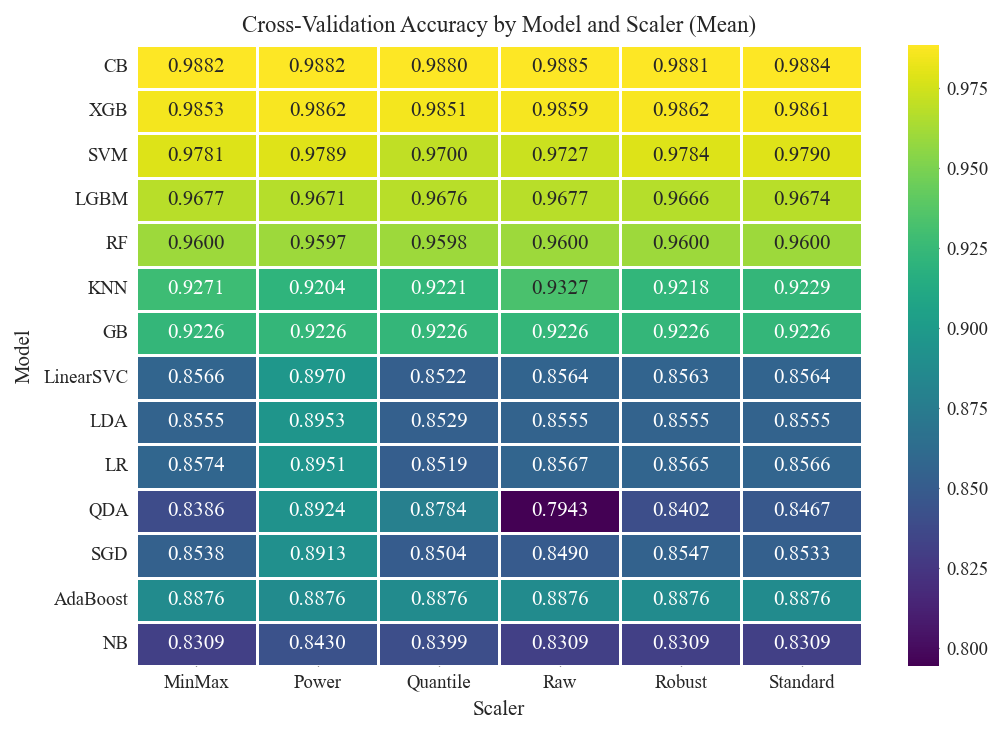

✓ Saved: heatmap_accuracy_mean.pdf and .png

CV Mean Accuracy by Model and Scaler:
Scaler     MinMax   Power  Quantile     Raw  Robust  Standard
Model                                                        
CB         0.9882  0.9882    0.9880  0.9885  0.9881    0.9884
XGB        0.9853  0.9862    0.9851  0.9859  0.9862    0.9861
SVM        0.9781  0.9789    0.9700  0.9727  0.9784    0.9790
LGBM       0.9677  0.9671    0.9676  0.9678  0.9666    0.9674
RF         0.9600  0.9597    0.9598  0.9600  0.9600    0.9600
KNN        0.9271  0.9204    0.9221  0.9327  0.9218    0.9229
GB         0.9226  0.9226    0.9226  0.9226  0.9226    0.9226
LinearSVC  0.8566  0.8970    0.8522  0.8564  0.8563    0.8564
LDA        0.8555  0.8953    0.8529  0.8555  0.8555    0.8555
LR         0.8574  0.8951    0.8519  0.8567  0.8565    0.8566
QDA        0.8386  0.8924    0.8784  0.7942  0.8402    0.8467
SGD        0.8538  0.8913    0.8504  0.8490  0.8547    0.8532
AdaBoost   0.8876  0.8876    0.8876  0.8876  0.88

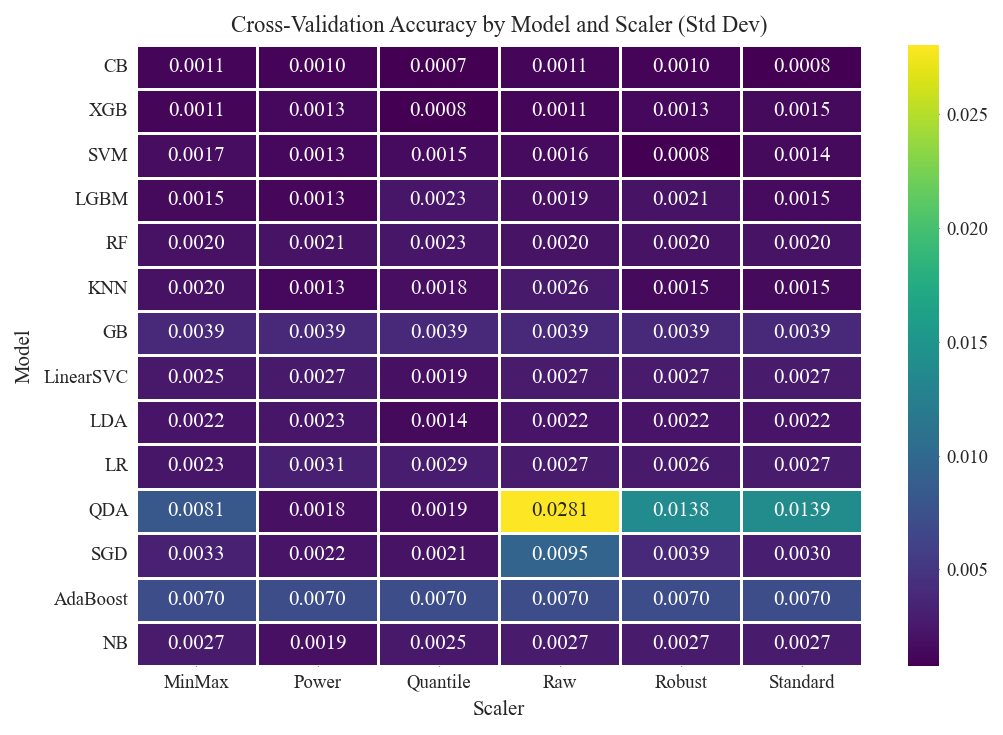

✓ Saved: heatmap_accuracy_std.pdf and .png

CV Std Dev Accuracy by Model and Scaler:
Scaler     MinMax   Power  Quantile     Raw  Robust  Standard
Model                                                        
CB         0.0011  0.0010    0.0007  0.0011  0.0010    0.0008
XGB        0.0011  0.0013    0.0008  0.0011  0.0013    0.0015
SVM        0.0017  0.0013    0.0015  0.0016  0.0008    0.0014
LGBM       0.0015  0.0013    0.0023  0.0019  0.0021    0.0015
RF         0.0020  0.0021    0.0023  0.0020  0.0020    0.0020
KNN        0.0020  0.0013    0.0018  0.0026  0.0015    0.0015
GB         0.0039  0.0039    0.0039  0.0039  0.0039    0.0039
LinearSVC  0.0025  0.0027    0.0019  0.0027  0.0027    0.0027
LDA        0.0022  0.0023    0.0014  0.0022  0.0022    0.0022
LR         0.0023  0.0031    0.0029  0.0027  0.0026    0.0027
QDA        0.0081  0.0018    0.0019  0.0281  0.0138    0.0139
SGD        0.0033  0.0022    0.0021  0.0095  0.0039    0.0030
AdaBoost   0.0070  0.0070    0.0070  0.0070  0.

In [40]:
FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Sort pivot table by max accuracy per model (descending)
accuracy_pivot_mean_sorted = accuracy_pivot_mean.reindex(
    accuracy_pivot_mean.max(axis=1).sort_values(ascending=False).index
)
accuracy_pivot_std_sorted = accuracy_pivot_std.reindex(accuracy_pivot_mean_sorted.index)

# ── Heatmap 1: Mean Accuracy ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 5))
sns.heatmap(accuracy_pivot_mean_sorted, annot=True, fmt='.4f', cmap='viridis',
            linewidths=0.5, ax=ax)
ax.set_title('Cross-Validation Accuracy by Model and Scaler (Mean)')
ax.set_xlabel('Scaler')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'heatmap_accuracy_mean.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'heatmap_accuracy_mean.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: heatmap_accuracy_mean.pdf and .png")

print("\nCV Mean Accuracy by Model and Scaler:")
print(accuracy_pivot_mean_sorted.round(4))

# ── Heatmap 2: Standard Deviation ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 5))
sns.heatmap(accuracy_pivot_std_sorted, annot=True, fmt='.4f', cmap='viridis',
            linewidths=0.5, ax=ax)
ax.set_title('Cross-Validation Accuracy by Model and Scaler (Std Dev)')
ax.set_xlabel('Scaler')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'heatmap_accuracy_std.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'heatmap_accuracy_std.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: heatmap_accuracy_std.pdf and .png")

print("\nCV Std Dev Accuracy by Model and Scaler:")
print(accuracy_pivot_std_sorted.round(4))


## Section 10: Visualizations - Scaling Sensitivity Bar Plot

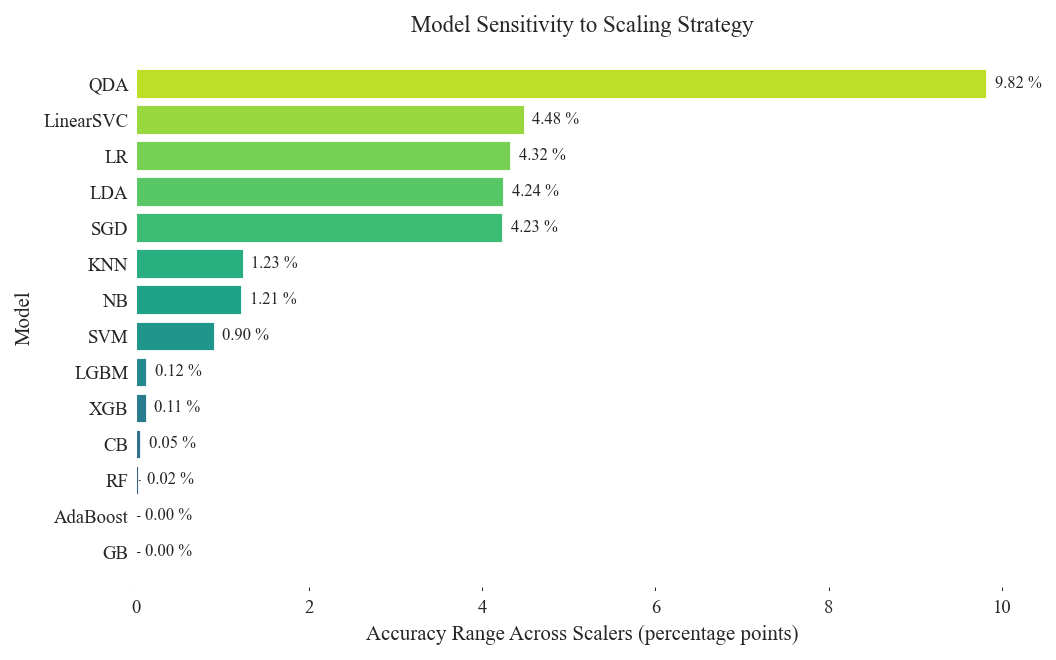

✓ Saved: scaling_sensitivity_barplot.pdf and .png


In [41]:
# Bar plot: Scaling sensitivity (range in percentage points)
fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 4.5))
sensitivity_sorted = sensitivity_df.sort_values('Range', ascending=True)
range_pct = sensitivity_sorted['Range'] * 100  # convert to percentage points

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(sensitivity_sorted)))
bars = ax.barh(sensitivity_sorted['Model'], range_pct, color=colors, edgecolor='white', linewidth=0.4)

# Annotate each bar with its value
for bar, val in zip(bars, range_pct):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f} %', va='center', fontsize=8)

ax.set_xlabel('Accuracy Range Across Scalers (percentage points)')
ax.set_ylabel('Model')
ax.set_title('Model Sensitivity to Scaling Strategy')

clean_ax(ax)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'scaling_sensitivity_barplot.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIGURES_DIR, 'scaling_sensitivity_barplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: scaling_sensitivity_barplot.pdf and .png")


## Section 11: Find Optimal Scaler Per Model

In [42]:
print("\n" + "=" * 80)
print("FINDING OPTIMAL SCALER PER MODEL")
print("=" * 80)

# Find optimal scaler per model
optimal_scalers = accuracy_pivot_mean.idxmax(axis=1)
optimal_accuracies = accuracy_pivot_mean.max(axis=1)
optimal_stds = []

for model_name in optimal_scalers.index:
    scaler_name = optimal_scalers[model_name]
    std_val = accuracy_pivot_std.loc[model_name, scaler_name]
    optimal_stds.append(std_val)

optimal_df = pd.DataFrame({
    'Model': optimal_scalers.index,
    'Optimal_Scaler': optimal_scalers.values,
    'CV_Accuracy_Mean': optimal_accuracies.values,
    'CV_Accuracy_Std': optimal_stds,
})

optimal_df = optimal_df.sort_values('CV_Accuracy_Mean', ascending=False).reset_index(drop=True)

print("\nOptimal Scaler per Model (sorted by CV Accuracy):")
print(optimal_df.to_string(index=False))

# Save optimal scalers
optimal_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_optimal_scalers.csv'), index=False)
print(f"\n✓ Saved: baseline_optimal_scalers.csv")



FINDING OPTIMAL SCALER PER MODEL

Optimal Scaler per Model (sorted by CV Accuracy):
    Model Optimal_Scaler  CV_Accuracy_Mean  CV_Accuracy_Std
       CB            Raw          0.988479         0.001121
      XGB          Power          0.986208         0.001290
      SVM       Standard          0.979021         0.001402
     LGBM            Raw          0.967750         0.001915
       RF         MinMax          0.959979         0.002021
      KNN            Raw          0.932667         0.002626
       GB         MinMax          0.922583         0.003934
LinearSVC          Power          0.897000         0.002657
      LDA          Power          0.895312         0.002253
       LR          Power          0.895083         0.003138
      QDA          Power          0.892437         0.001838
      SGD          Power          0.891271         0.002202
 AdaBoost         MinMax          0.887562         0.007040
       NB          Power          0.843042         0.001900

✓ Saved: basel

## Section 12: Train Final Models with Optimal Scalers

In [45]:
print("\n" + "=" * 80)
print("TRAINING FINAL MODELS WITH OPTIMAL SCALERS")
print("=" * 80)

final_results = []

for idx, row in optimal_df.iterrows():
    model_name = row['Model']
    scaler_name = row['Optimal_Scaler']
    
    model = models[model_name]
    scaler = scalers[scaler_name]
    
    # Apply scaling
    if scaler is None:
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
    else:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predict — timed for inference benchmarking
    t_infer_start = time.perf_counter()
    y_pred = model.predict(X_test_scaled)
    infer_time = time.perf_counter() - t_infer_start
    
    # Get probabilities if available
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred_proba = None
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
        ll = log_loss(y_test, y_pred_proba)
    else:
        auc = np.nan
        ll = np.nan
    
    final_results.append({
        'Model': model_name,
        'Optimal_Scaler': scaler_name,
        'Test_Accuracy': acc,
        'Test_F1': f1,
        'Test_MCC': mcc,
        'Test_Precision': prec,
        'Test_Recall': rec,
        'Test_AUC': auc,
        'Test_LogLoss': ll,
        'Test_Kappa': kappa,
        'CV_Accuracy_Mean': row['CV_Accuracy_Mean'],
        'CV_Accuracy_Std': row['CV_Accuracy_Std'],
        'Inference_Time_s': infer_time,
    })
    
    print(f"{model_name:12} ({scaler_name:10}): Test Acc={acc:.4f}, CV Acc={row['CV_Accuracy_Mean']:.4f}±{row['CV_Accuracy_Std']:.4f}")

final_results_df = pd.DataFrame(final_results)
final_results_df = final_results_df.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)

# Save results
final_results_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_results_final.csv'), index=False)
print(f"\n✓ Saved: baseline_results_final.csv")



TRAINING FINAL MODELS WITH OPTIMAL SCALERS
CB           (Raw       ): Test Acc=0.9922, CV Acc=0.9885±0.0011
XGB          (Power     ): Test Acc=0.9899, CV Acc=0.9862±0.0013
SVM          (Standard  ): Test Acc=0.9823, CV Acc=0.9790±0.0014
LGBM         (Raw       ): Test Acc=0.9711, CV Acc=0.9677±0.0019
RF           (MinMax    ): Test Acc=0.9690, CV Acc=0.9600±0.0020
KNN          (Raw       ): Test Acc=0.9394, CV Acc=0.9327±0.0026
GB           (MinMax    ): Test Acc=0.9263, CV Acc=0.9226±0.0039
LinearSVC    (Power     ): Test Acc=0.9052, CV Acc=0.8970±0.0027
LDA          (Power     ): Test Acc=0.9035, CV Acc=0.8953±0.0023
LR           (Power     ): Test Acc=0.9030, CV Acc=0.8951±0.0031
QDA          (Power     ): Test Acc=0.9016, CV Acc=0.8924±0.0018
SGD          (Power     ): Test Acc=0.8956, CV Acc=0.8913±0.0022
AdaBoost     (MinMax    ): Test Acc=0.8935, CV Acc=0.8876±0.0070
NB           (Power     ): Test Acc=0.8475, CV Acc=0.8430±0.0019

✓ Saved: baseline_results_final.csv


## Section 13: Summary and Interpretation

### Key Findings

1. **Top performers.** CatBoost (Raw) achieved the highest test accuracy of 99.23% (F1 = 0.994, MCC = 0.983), followed closely by XGBoost (Power) at 98.99%. Both models also recorded near-perfect AUC (≥ 0.999), confirming strong discrimination between stable and unstable classes.

2. **Tree-based models are scaling-invariant.** The five least scaling-sensitive models — AdaBoost, GB, RF, CB, and LGBM — showed accuracy ranges of < 0.1 pp across all six scalers. Their optimal scalers were either Raw or MinMax, indicating that explicit feature transformation adds no benefit for tree-based ensembles.

3. **Linear and probabilistic models benefit from Power/Quantile transforms.** LR, LDA, LinearSVC, SGD, QDA, and NB all achieved their best CV accuracy under PowerTransformer. Their accuracy ranges across scalers spanned 4–10 pp, with QDA being the most sensitive (range = 9.86 pp).

4. **Strong CV–test agreement.** All 14 models showed test accuracy within ~1 pp of their CV mean, and CV standard deviations stayed below 0.7%, indicating stable generalisation without overfitting at the baseline stage.

5. **Practical implication for the pipeline.** Model-specific optimal scalers determined here are carried forward to Notebook 04 (hyperparameter tuning), eliminating scaling as a confounding variable in subsequent experiments.


## Section 14: Baseline Summary Files for HPO Comparison

The following cells produce clean, standardised output files used directly in HPO comparison notebooks.


In [46]:
# ── baseline_cv_summary.csv ────────────────────────────────────────────────
# CV results for the selected scaler only (used for HPO comparison tables)

baseline_cv_summary = optimal_df[['Model', 'Optimal_Scaler', 'CV_Accuracy_Mean', 'CV_Accuracy_Std']].copy()
baseline_cv_summary = baseline_cv_summary.rename(columns={
    'CV_Accuracy_Mean': 'CV_Mean',
    'CV_Accuracy_Std': 'CV_Std',
})

baseline_cv_summary.to_csv(os.path.join(RESULTS_DIR, 'baseline_cv_summary.csv'), index=False)
print("baseline_cv_summary.csv")
print(baseline_cv_summary.to_string(index=False))
print(f"\n✓ Saved: baseline_cv_summary.csv ({len(baseline_cv_summary)} rows)")


baseline_cv_summary.csv
    Model Optimal_Scaler  CV_Mean   CV_Std
       CB            Raw 0.988479 0.001121
      XGB          Power 0.986208 0.001290
      SVM       Standard 0.979021 0.001402
     LGBM            Raw 0.967750 0.001915
       RF         MinMax 0.959979 0.002021
      KNN            Raw 0.932667 0.002626
       GB         MinMax 0.922583 0.003934
LinearSVC          Power 0.897000 0.002657
      LDA          Power 0.895312 0.002253
       LR          Power 0.895083 0.003138
      QDA          Power 0.892437 0.001838
      SGD          Power 0.891271 0.002202
 AdaBoost         MinMax 0.887562 0.007040
       NB          Power 0.843042 0.001900

✓ Saved: baseline_cv_summary.csv (14 rows)


In [47]:
# ── optimal_scaler_fold_scores.csv ────────────────────────────────────────
# Per-fold CV accuracy for the selected scaler only — used for baseline vs HPO
# statistical comparison (e.g. Wilcoxon signed-rank test across folds)

# Merge per-fold results with optimal scaler per model, keep matching rows only
fold_df = results_per_fold_df.merge(
    optimal_df[['Model', 'Optimal_Scaler']],
    left_on=['Model', 'Scaler'],
    right_on=['Model', 'Optimal_Scaler'],
    how='inner',
)

# Pivot to wide format: one column per fold
fold_wide = fold_df.pivot_table(index='Model', columns='Fold', values='Accuracy')
fold_wide.columns = [f'Fold_{int(c)}' for c in fold_wide.columns]
fold_wide = fold_wide.reset_index()

# Add Optimal_Scaler, Mean, Std
fold_wide = fold_wide.merge(optimal_df[['Model', 'Optimal_Scaler']], on='Model')
fold_cols = [c for c in fold_wide.columns if c.startswith('Fold_')]
fold_wide['Mean'] = fold_wide[fold_cols].mean(axis=1)
fold_wide['Std'] = fold_wide[fold_cols].std(axis=1, ddof=0)

# Reorder columns
fold_wide = fold_wide[['Model', 'Optimal_Scaler'] + fold_cols + ['Mean', 'Std']]
fold_wide = fold_wide.sort_values('Mean', ascending=False).reset_index(drop=True)

fold_wide.to_csv(os.path.join(RESULTS_DIR, 'optimal_scaler_fold_scores.csv'), index=False)
print("optimal_scaler_fold_scores.csv")
print(fold_wide.to_string(index=False))
print(f"\n✓ Saved: optimal_scaler_fold_scores.csv ({len(fold_wide)} rows)")


optimal_scaler_fold_scores.csv
    Model Optimal_Scaler   Fold_1   Fold_2   Fold_3   Fold_4   Fold_5     Mean      Std
       CB            Raw 0.988542 0.986875 0.987604 0.989792 0.989583 0.988479 0.001121
      XGB          Power 0.984271 0.987604 0.987187 0.986875 0.985104 0.986208 0.001290
      SVM       Standard 0.978437 0.977292 0.978958 0.981563 0.978854 0.979021 0.001402
     LGBM            Raw 0.964583 0.966875 0.969688 0.969688 0.967917 0.967750 0.001915
       RF         MinMax 0.957917 0.962917 0.961771 0.958021 0.959271 0.959979 0.002021
      KNN            Raw 0.931250 0.929479 0.937292 0.933333 0.931979 0.932667 0.002626
       GB         MinMax 0.918125 0.926667 0.925104 0.925521 0.917500 0.922583 0.003934
LinearSVC          Power 0.896667 0.895833 0.893333 0.897708 0.901458 0.897000 0.002657
      LDA          Power 0.895104 0.894271 0.892708 0.895000 0.899479 0.895312 0.002253
       LR          Power 0.892396 0.896146 0.890833 0.896354 0.899687 0.895083 0.003138
 

In [48]:
# ── baseline_test_results_clean.csv ──────────────────────────────────────
# Standardised test metrics — no Test_ prefix, columns ordered for comparison

col_map = {
    'Test_Accuracy': 'Accuracy',
    'Test_Precision': 'Precision',
    'Test_Recall': 'Recall',
    'Test_F1': 'F1',
    'Test_AUC': 'AUC',
    'Test_LogLoss': 'LogLoss',
    'Test_Kappa': 'Kappa',
    'Test_MCC': 'MCC',
}

baseline_test_clean = final_results_df[['Model', 'Optimal_Scaler'] + list(col_map.keys())].copy()
baseline_test_clean = baseline_test_clean.rename(columns=col_map)

baseline_test_clean.to_csv(os.path.join(RESULTS_DIR, 'baseline_test_results_clean.csv'), index=False)
print("baseline_test_results_clean.csv")
print(baseline_test_clean.to_string(index=False))
print(f"\n✓ Saved: baseline_test_results_clean.csv ({len(baseline_test_clean)} rows)")


baseline_test_results_clean.csv
    Model Optimal_Scaler  Accuracy  Precision   Recall       F1      AUC  LogLoss    Kappa      MCC
       CB            Raw  0.992250   0.991423 0.996473 0.993942 0.999531 0.058745 0.983189 0.983214
      XGB          Power  0.989917   0.991135 0.993077 0.992105 0.999428 0.044995 0.978154 0.978158
      SVM       Standard  0.982333   0.984635 0.987722 0.986176 0.998714 0.043883 0.961707 0.961716
     LGBM            Raw  0.971083   0.971488 0.983542 0.977478 0.996897 0.106920 0.937100 0.937239
       RF         MinMax  0.969000   0.967402 0.984587 0.975919 0.996245 0.138566 0.932430 0.932715
      KNN            Raw  0.939417   0.946514 0.959248 0.952838 0.982171 0.278671 0.868166 0.868318
       GB         MinMax  0.926250   0.928490 0.958203 0.943112 0.982510 0.204890 0.838366 0.839206
LinearSVC          Power  0.905167   0.917928 0.934953 0.926362      NaN      NaN 0.793232 0.793496
      LDA          Power  0.903500   0.917287 0.932863 0.925010 0.96

In [49]:
# ── baseline_inference_time.csv ───────────────────────────────────────────
# Prediction time measured in Section 12 for the final fitted baseline model

n_test_samples = len(X_test)

baseline_infer = final_results_df[['Model', 'Optimal_Scaler', 'Inference_Time_s']].copy()
baseline_infer = baseline_infer.rename(columns={'Inference_Time_s': 'Inference_Time_Total_Sec'})
baseline_infer['Inference_Time_Per_Sample_Us'] = (
    baseline_infer['Inference_Time_Total_Sec'] / n_test_samples * 1_000_000
)

baseline_infer.to_csv(os.path.join(RESULTS_DIR, 'baseline_inference_time.csv'), index=False)
print("baseline_inference_time.csv")
print(baseline_infer.to_string(index=False))
print(f"\n✓ Saved: baseline_inference_time.csv ({len(baseline_infer)} rows, {n_test_samples} test samples)")


baseline_inference_time.csv
    Model Optimal_Scaler  Inference_Time_Total_Sec  Inference_Time_Per_Sample_Us
       CB            Raw                  0.049186                      4.098800
      XGB          Power                  0.009118                      0.759825
      SVM       Standard                  5.650246                    470.853808
     LGBM            Raw                  0.024783                      2.065267
       RF         MinMax                  0.038321                      3.193383
      KNN            Raw                  1.322601                    110.216725
       GB         MinMax                  0.018052                      1.504317
LinearSVC          Power                  0.012565                      1.047067
      LDA          Power                  0.000445                      0.037108
       LR          Power                  0.000800                      0.066667
      QDA          Power                  0.005654                      0.471158


In [50]:
print("\n" + "=" * 80)
print("NOTEBOOK 03 COMPLETE")
print("=" * 80)
print(f"\nGenerated Files:")
print(f"  1.  scaling_experiments_mean_std.csv   — Mean ± Std for all combinations")
print(f"  2.  scaling_experiments_per_fold.csv   — Individual fold results")
print(f"  3.  scaling_sensitivity.csv            — Sensitivity metrics")
print(f"  4.  accuracy_pivot_mean.csv            — Mean accuracy pivot table")
print(f"  5.  accuracy_pivot_std.csv             — Std accuracy pivot table")
print(f"  6.  baseline_optimal_scalers.csv       — Optimal scaler per model")
print(f"  7.  baseline_results_final.csv         — Final test results (extended)")
print(f"  8.  heatmap_accuracy_mean.png          — Mean accuracy heatmap")
print(f"  9.  heatmap_accuracy_std.png           — Std accuracy heatmap")
print(f"  10. scaling_sensitivity_barplot.png    — Sensitivity bar plot")
print(f"\nBaseline summary files (for HPO comparison):")
print(f"  11. baseline_cv_summary.csv            — CV results for selected scaler only")
print(f"  12. optimal_scaler_fold_scores.csv     — Per-fold accuracy (Fold_1..5, Mean, Std)")
print(f"  13. baseline_test_results_clean.csv    — Clean test metrics (Accuracy, F1, AUC, LogLoss, Kappa, MCC)")
print(f"  14. baseline_inference_time.csv        — Inference time per model on test set")
print(f"\nNext: Notebook 04 - Hyperparameter Optimization")



NOTEBOOK 03 COMPLETE

Generated Files:
  1.  scaling_experiments_mean_std.csv   — Mean ± Std for all combinations
  2.  scaling_experiments_per_fold.csv   — Individual fold results
  3.  scaling_sensitivity.csv            — Sensitivity metrics
  4.  accuracy_pivot_mean.csv            — Mean accuracy pivot table
  5.  accuracy_pivot_std.csv             — Std accuracy pivot table
  6.  baseline_optimal_scalers.csv       — Optimal scaler per model
  7.  baseline_results_final.csv         — Final test results (extended)
  8.  heatmap_accuracy_mean.png          — Mean accuracy heatmap
  9.  heatmap_accuracy_std.png           — Std accuracy heatmap
  10. scaling_sensitivity_barplot.png    — Sensitivity bar plot

Baseline summary files (for HPO comparison):
  11. baseline_cv_summary.csv            — CV results for selected scaler only
  12. optimal_scaler_fold_scores.csv     — Per-fold accuracy (Fold_1..5, Mean, Std)
  13. baseline_test_results_clean.csv    — Clean test metrics (Accuracy, F1